In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

In [2]:
train_df = pd.read_csv('data/잔액정보_with_segment.csv')

In [3]:
train_df.info()
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Data columns (total 83 columns):
 #   Column             Dtype  
---  ------             -----  
 0   기준년월               int64  
 1   ID                 object 
 2   잔액_일시불_B0M         int64  
 3   잔액_할부_B0M          int64  
 4   잔액_현금서비스_B0M       int64  
 5   잔액_리볼빙일시불이월_B0M    int64  
 6   잔액_리볼빙CA이월_B0M     int64  
 7   잔액_카드론_B0M         int64  
 8   월중평잔_일시불_B0M       int64  
 9   월중평잔_할부_B0M        int64  
 10  월중평잔_CA_B0M        int64  
 11  카드론잔액_최종경과월        int64  
 12  연체일자_B0M           float64
 13  연체잔액_B0M           int64  
 14  연체잔액_일시불_B0M       int64  
 15  연체잔액_할부_B0M        int64  
 16  연체잔액_현금서비스_B0M     int64  
 17  연체잔액_카드론_B0M       int64  
 18  연체잔액_대환론_B0M       int64  
 19  잔액_현금서비스_B1M       int64  
 20  잔액_현금서비스_B2M       int64  
 21  잔액_카드론_B1M         int64  
 22  잔액_카드론_B2M         int64  
 23  잔액_카드론_B3M         int64  
 24  잔액_카드론_B4M         int64  
 25  잔액_카드론_B5M        

기준년월            0
ID              0
잔액_일시불_B0M      0
잔액_할부_B0M       0
잔액_현금서비스_B0M    0
               ..
평잔_할부_해외_6M     0
평잔_CA_6M        0
평잔_CA_해외_6M     0
평잔_카드론_6M       0
Segment         0
Length: 83, dtype: int64

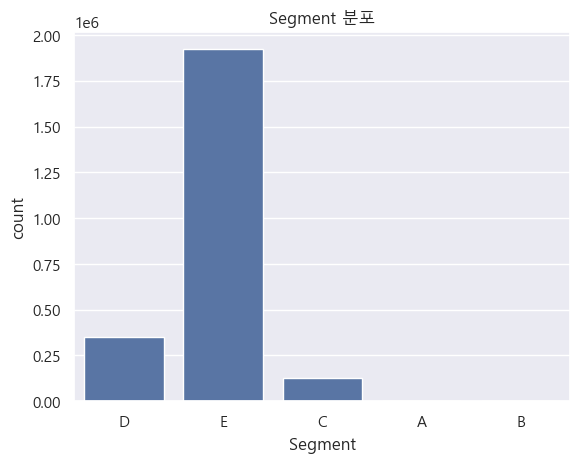

In [4]:
sns.countplot(data=train_df, x='Segment')
plt.title('Segment 분포')
plt.show()

In [5]:
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

In [6]:
# sns.boxplot(data=train_df, x='Segment', y='혜택수혜금액_R3M')

In [7]:
# sns.countplot(data=train_df, x='청구서발송여부_B0', hue='Segment')

In [8]:
from sklearn.preprocessing import LabelEncoder

train_df2 = train_df.copy()
le = LabelEncoder()
train_df2['Segment_encoded'] = le.fit_transform(train_df2['Segment'])


In [9]:
numeric_cols = train_df2.select_dtypes(include=['int64', 'float64']).columns.tolist()

corr_series = train_df2[numeric_cols].corrwith(train_df2['Segment_encoded']).sort_values(key=abs, ascending=False)
display(corr_series.head(20))


평잔_일시불_6M      -0.447967
월중평잔_일시불_B0M   -0.444621
월중평잔_일시불       -0.441527
평잔_일시불_3M      -0.434514
잔액_일시불_B0M     -0.417354
잔액_일시불_B1M     -0.374244
잔액_일시불_B2M     -0.373494
평잔_일시불_해외_6M   -0.312756
평잔_일시불_해외_3M   -0.292834
월중평잔           -0.287289
평잔_6M          -0.281497
평잔_CA_6M       -0.273914
평잔_3M          -0.268472
평잔_CA_3M       -0.267652
월중평잔_CA        -0.266320
잔액_현금서비스_B2M   -0.265487
잔액_현금서비스_B0M   -0.265011
잔액_현금서비스_B1M   -0.264744
잔액_할부_B0M      -0.264292
월중평잔_CA_B0M    -0.264076
dtype: float64

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1) + 1e-10)))

cat_cols = train_df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Segment']

cramer_dict = {}
for col in cat_cols:
    try:
        cramer_dict[col] = cramers_v(train_df[col], train_df['Segment'])
    except:
        cramer_dict[col] = np.nan

cramer_series = pd.Series(cramer_dict).sort_values(ascending=False)
display(cramer_series.head(10))


ID    1.0
dtype: float64

In [11]:
# 예: 수치형 중 절댓값 기준 0.2 이상
high_corr_num = corr_series[abs(corr_series) > 0.3].index.tolist()

# 범주형 중 Cramér’s V 기준 0.2 이상
high_corr_cat = cramer_series[cramer_series > 0.3].index.tolist()

# 최종 관심 컬럼
important_cols = high_corr_num + high_corr_cat
print("Segment와 관련 높은 컬럼:")
print(important_cols)


Segment와 관련 높은 컬럼:
['평잔_일시불_6M', '월중평잔_일시불_B0M', '월중평잔_일시불', '평잔_일시불_3M', '잔액_일시불_B0M', '잔액_일시불_B1M', '잔액_일시불_B2M', '평잔_일시불_해외_6M', 'ID']


In [12]:
results = []

for col in train_df2.columns:
    if col in ['Segment', 'Segment_encoded']:
        continue  # 타겟은 제외
    
    dtype = train_df2[col].dtype
    var_type = '수치형' if dtype in ['int64', 'float64'] else '범주형'

    # 상관계수 (수치형만 계산 가능)
    try:
        corr = train_df2[[col, 'Segment_encoded']].corr().iloc[0, 1] if var_type == '수치형' else None
    except:
        corr = None

    results.append({
        '컬럼명': col,
        '변수 타입': var_type,
        'Segment 상관계수': corr
    })

# 정렬 및 출력
result_df = pd.DataFrame(results).sort_values(by='Segment 상관계수', key=lambda x: x.abs() if x.name == 'Segment 상관계수' else x, ascending=False)
display(result_df.head(30))

,컬럼명,변수 타입,Segment 상관계수
73,평잔_일시불_6M,수치형,-0.447967
8,월중평잔_일시불_B0M,수치형,-0.444621
57,월중평잔_일시불,수치형,-0.441527
63,평잔_일시불_3M,수치형,-0.434514
2,잔액_일시불_B0M,수치형,-0.417354
28,잔액_일시불_B1M,수치형,-0.374244
29,잔액_일시불_B2M,수치형,-0.373494
74,평잔_일시불_해외_6M,수치형,-0.312756
64,평잔_일시불_해외_3M,수치형,-0.292834
56,월중평잔,수치형,-0.287289


In [13]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Cramér's V 함수 정의
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.shape[0] == 1 or confusion_matrix.shape[1] == 1:
        return np.nan  # 너무 적은 범주 제외
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1) + 1e-10)))

# 범주형 변수 리스트
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Segment']

# 결과 저장
cramer_results = []
for col in cat_cols:
    try:
        val = cramers_v(train_df[col], train_df['Segment'])
    except:
        val = np.nan
    cramer_results.append({'컬럼명': col, '변수 타입': '범주형', 'Cramér\'s V': val})

# 출력
cramer_df = pd.DataFrame(cramer_results).sort_values(by="Cramér's V", ascending=False)
display(cramer_df)


,컬럼명,변수 타입,Cramér's V
0,ID,범주형,1.0


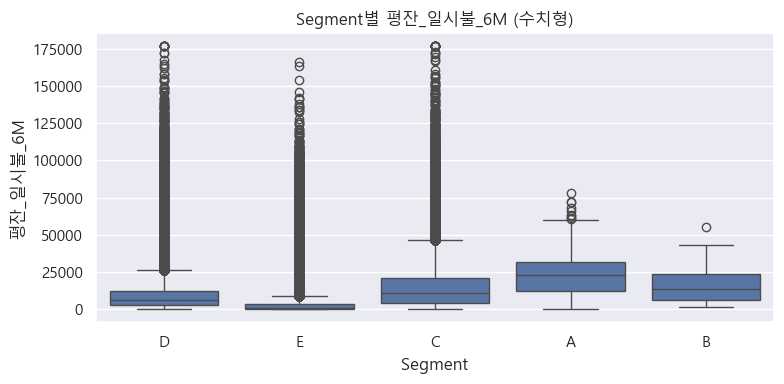

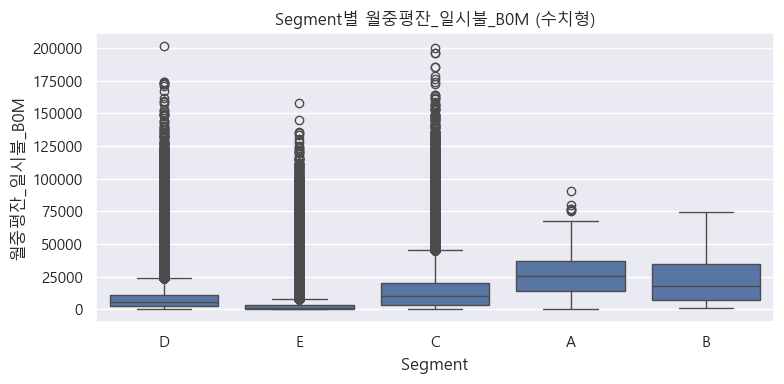

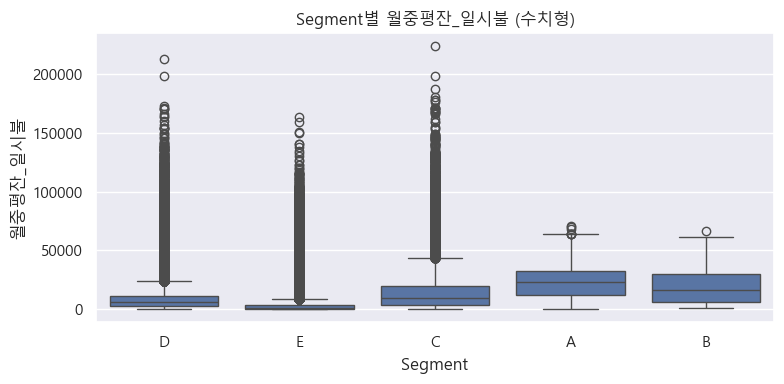

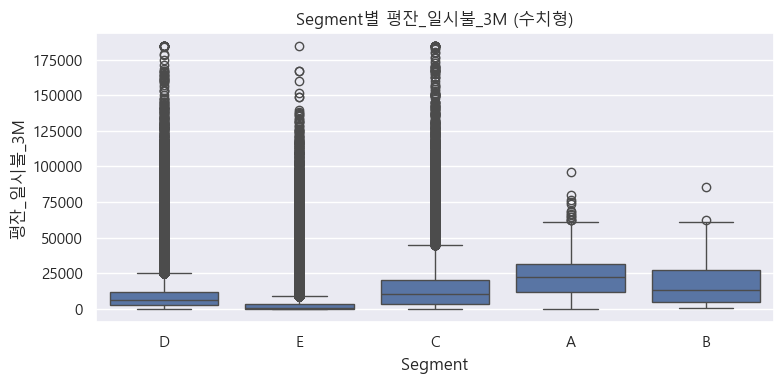

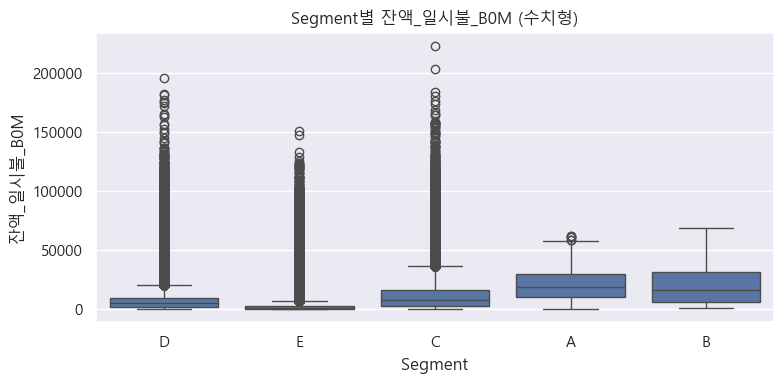

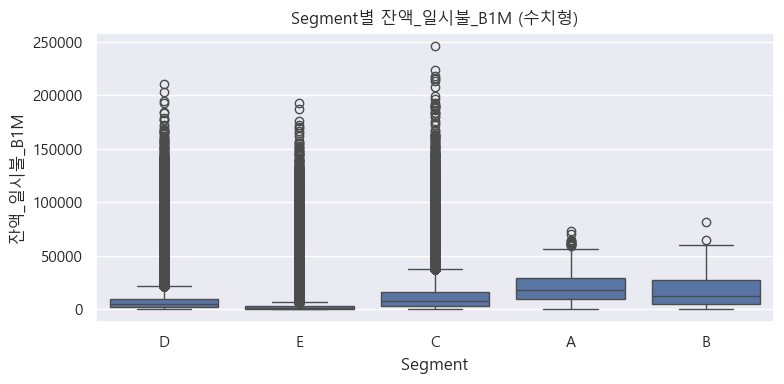

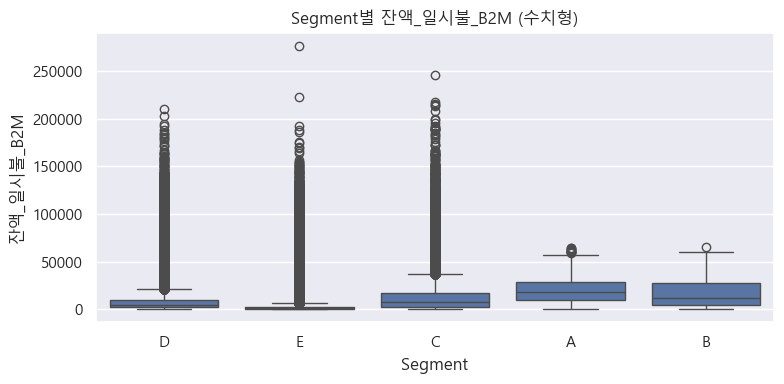

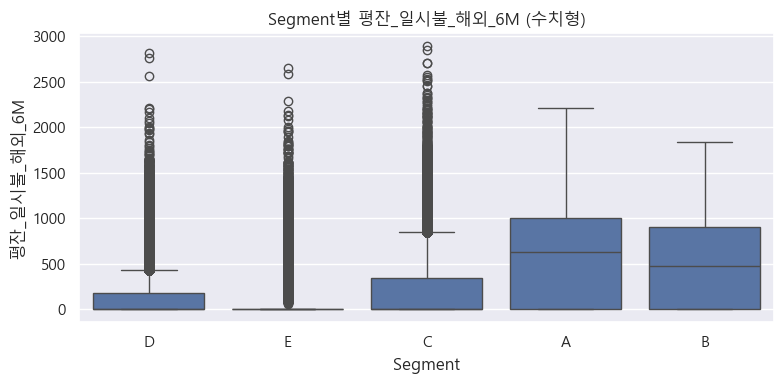

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Segment와 상관 높은 변수 리스트
important_cols = [
   '평잔_일시불_6M', '월중평잔_일시불_B0M', '월중평잔_일시불', '평잔_일시불_3M', 
    '잔액_일시불_B0M', '잔액_일시불_B1M', '잔액_일시불_B2M', '평잔_일시불_해외_6M',
]

# 수치형, 범주형 자동 분류
numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = [col for col in important_cols if col not in numeric_cols]

# 시각화
for col in important_cols:
    plt.figure(figsize=(8, 4))
    
    if col in numeric_cols:
        # 수치형: boxplot
        sns.boxplot(data=train_df, x='Segment', y=col)
        plt.title(f'Segment별 {col} (수치형)')
    else:
        # 범주형: countplot
        sns.countplot(data=train_df, x=col, hue='Segment')
        plt.title(f'{col}별 Segment 분포 (범주형)')
        plt.xticks(rotation=30)
    
    plt.tight_layout()
    plt.show()
